# Ugentlig udbrudsprognose for anmeldepligtig sygdom til folkesundhedsovervågning

## Sammenfatning

En delstatslig enhed for folkesundhedsovervågning modtager ugentlige optællinger af en anmeldepligtig luftvejssygdom og skal fremskrive de næste to måneders sygdomsbyrde for på forhånd at placere personale, laboratoriekapacitet og lagre af antivirale midler. Denne notebook opbygger en selvstændig syntetisk overvågningsserie på 78 uger (18 måneder) med en langsomt stigende tendens og en sæsonbølge inden for året og analyserer den derefter fra ende til anden med tre SAS 9.4-procedurer.

PROC MEANS opsummerer sygdomsbyrden efter sæson og kvantificerer, hvor meget tungere vinter- og efterårsuger belastes end sommeren. PROC TIMESERIES akkumulerer de ugentlige observationer på et regelmæssigt WEEK-interval og beregner en sæsonprofil (SEASON-sætningen), så teamet kan se, hvilke uger i sæsoncyklussen der systematisk kører varmt eller koldt. PROC ARIMA tilpasser derefter en ARIMA(1,1,1)-model — første differens fjerner tendensen — og producerer en 8-ugers prognose med daterede horisontrækker, hvilket giver overvågningsenheden et konkret, modelbaseret udsyn til ressourceplanlægning.

Arbejdsgangen er fuldt reproducerbar (et fast STREAMINIT-frø), kører på et godt stykke under et minut og afspejler, hvordan en epidemiolog ville bevæge sig fra beskrivende byrde til sæsonstruktur til en fremadrettet prognose. Fortolkningsceller oversætter hver procedures output til den overvågningsbeslutning, det understøtter.

## Datakilder

Alle data er syntetiske og genereres inline af det første DATA step (ingen eksterne input eller netværksinput). Et fast frø (`call streaminit(20260606)`) gør serien reproducerbar.

**Syntetisk datasæt: `surveillance`** — 78 ugentlige observationer (én rapporteringsregion for anmeldepligtig sygdom, fra jan. 2025 og frem)

| Variabel | Type | Beskrivelse |
|----------|------|-------------|
| `reportdate` | Num (DATE9.) | Mandag i rapporteringsugen |
| `week` | Num | Fortløbende ugeindeks, 1-78 |
| `cases` | Num | Ugentligt antal bekræftede tilfælde (tendens + sæsonbølge + støj, gulvsat ved 0) |
| `season` | Char | Meteorologisk sæsonmærkat: Winter, Spring, Summer, Fall |

Den datagenererende proces er `cases = round(max(0, 30 + 0.18*week + 12*sin(2*pi*doy/52 + 1.3) + N(0, 3.5)))`, som kombinerer en blid stigende tendens, en årlig sæsoncyklus og gaussisk rapporteringsstøj.

# Ugentlig udbrudsprognose for anmeldepligtig sygdom

**Kontekst.** En delstatslig enhed for folkesundhedsovervågning følger ugentlige bekræftede optællinger af en anmeldepligtig luftvejssygdom. For at bemande udbrudsberedskabsteams, planlægge laboratoriekapacitet og dimensionere lagre af antivirale midler har enheden brug for en prognose på kort sigt af sygdomsbyrden samt en forståelse af det sæsonmønster, der driver den.

**Analyseplan.**

1. **PROC MEANS** — beskriv sygdomsbyrden efter sæson (hvor er belastningen koncentreret?).
2. **PROC TIMESERIES** — akkumulér til et regelmæssigt ugentligt interval og udtræk en *sæsonprofil* på tværs af sæsoncyklussen.
3. **PROC ARIMA** — tilpas en ARIMA-model på den (differentierede) ugentlige serie og prognosticér de næste 8 uger til ressourceplanlægning.

Alle data er syntetiske og genereres inline nedenfor, så denne notebook er fuldt selvstændig og reproducerbar.

## 1. Generér den syntetiske overvågningsserie

Vi simulerer 78 uger (cirka 18 måneder) af ugentlige antal tilfælde. Den datagenererende proces lag-opbygger tre realistiske komponenter: en blid stigende **tendens** (stigende baselineincidens), en årlig **sæsonbølge** (en sinusoide over det 52-ugers år, med top i de kolde måneder) og gaussisk **rapporteringsstøj**. Antallene gulvsættes ved nul og afrundes til heltal. Et `season`-mærkat vedhæftes til det beskrivende trin.

In [1]:
data surveillance;
   CALL streaminit(20260606);
   START = '06JAN2025'd;
   GØR week = 1 TIL 78;
      reportdate = START + (week-1)*7;
      doy = mod(week, 52);
      season_amp = 12 * sin(2*constant('pi')*doy/52 + 1.3);
      trend = 0.18 * week;
      BASE = 30 + trend + season_amp;
      noise = rand('normal', 0, 3.5);
      cases = round(MAX(0, BASE + noise));
      LÆNGDE season $10;
      HVIS 14 <= doy <= 26 SÅ season = 'Forår';
      ELLERS HVIS 27 <= doy <= 39 SÅ season = 'Sommer';
      ELLERS HVIS 40 <= doy <= 52 SÅ season = 'Efterår';
      ELLERS season = 'Vinter';
      UDDATA;
   SLUT;
   BEHOLD reportdate week cases season;
   format reportdate date9.;
KØR;

PROCEDURE UDSKRIV data=surveillance(obs=8) MÆRKAT noobs;
   VARIABEL reportdate week cases season;
   MÆRKAT reportdate="Rapportdato" week="Uge" cases="Tilfælde" season="Sæson";
   TITEL 'Første 8 uger af den syntetiske overvågningsserie';
KØR;

                                   Første 8 uger af den syntetiske overvågningsserie                                    

Rapportdato  Uge   Tilfælde   Sæson
  06JAN2025    1         43  Vinter
  13JAN2025    2         40  Vinter
  20JAN2025    3         46  Vinter
  27JAN2025    4         47  Vinter
  03FEB2025    5         42  Vinter
  10FEB2025    6         39  Vinter
  17FEB2025    7         40  Vinter
  24FEB2025    8         41  Vinter

... 70 more observations (showing 8 of 78)




NOTE: DATA surveillance


NOTE: Wrote surveillance (78 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=surveillance

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


## 2. Sæsonbyrde med PROC MEANS

Før nogen modellering kvantificerer vi, hvordan sygdomsbyrden fordeler sig på tværs af sæsoner. Dette er det beskrivende billede, som en overvågningsepidemiolog tager udgangspunkt i: hvilke sæsoner kører rutinemæssigt varmt, og hvor variabelt er det ugentlige antal inden for hver? `CLASS season` opdeler ugerne; vi rapporterer N, gennemsnit, standardafvigelse og min/maks-spændet.

In [2]:
PROCEDURE GENNEMSNIT data=surveillance n mean std MIN MAX maxdec=1;
   KLASSE season;
   VARIABEL cases;
   MÆRKAT cases="Tilfælde" season="Sæson";
   TITEL 'Ugentlig sygdomsbyrde efter sæson';
KØR;

                                           Ugentlig sygdomsbyrde efter sæson                                            

                                                  The MEANS Procedure

                                          Analysis Variable : cases Tilfælde

        Sæson             N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        Efterår              12           43.3            5.2           32.0           50.0
        Forår                26           33.2            6.6           23.0           47.0
        Sommer               13           27.8            4.5           22.0           39.0
        Vinter               27           44.8            7.2           30.0           60.0
        -----------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


**Sådan læses det.** Vinter- og efterårsuger bærer den tungeste gennemsnitlige sygdomsbyrde, sommeren den letteste — det forventede mønster for en sæsonbetinget luftvejssygdom. Standardafvigelsen inden for sæsonen fortæller enheden, hvor meget uge-til-uge-stigning der skal planlægges for selv inden for en enkelt sæson; vinteren viser både det højeste gennemsnit og den bredeste spredning, så den berettiger den største stående beredskabskapacitet.

## 3. Sæsonprofil med PROC TIMESERIES

PROC TIMESERIES **akkumulerer** først observationerne på et strengt regelmæssigt interval (her `INTERVAL=WEEK`, hvor `ACCUMULATE=TOTAL` summerer eventuelle rapporter inden for ugen), hvilket garanterer en jævnt fordelt serie til efterfølgende modellering. Vi sætter derefter `SEASONALITY=13` — en 13-ugers (kvartalsvis) sæsoncyklus — og bruger `SEASON`-sætningen til for hver position i cyklussen at beregne gennemsnit, standardafvigelse og antal. Dette isolerer det systematiske sæsonsignal fra tendensen og støjen.

In [3]:
PROCEDURE TIMESERIES data=surveillance seasonality=13
                outseason=seasonprofile UDSKRIV=(seasons);
   id reportdate interval=week accumulate=TOTAL;
   VARIABEL cases;
   season n mean STDDEV;
   TITEL 'Sæsonprofil for ugentlige tilfælde';
KØR;

PROCEDURE UDSKRIV data=seasonprofile noobs;
   TITEL 'OUTSEASON= sæsonstatistik efter cykluspositon';
KØR;

                                           Ugentlig sygdomsbyrde efter sæson                                            

                                     OUTSEASON= sæsonstatistik efter cykluspositon                                      

_SEASON_  _NAME_    INDEX  N  MIN  MAX     MEAN   STDDEV
       1  CASES    -1.316  6   24   50     37.5   9.2898
       2  CASES    1.7763  6   22   55     39.5  11.3622
       3  CASES   -0.1621  6   28   47  38.8333   8.1343
       4  CASES   -4.7006  6   24   47  35.3333   9.4587
       5  CASES    3.5456  6   27   60  41.3333  11.6905
       6  CASES    2.4225  6   26   56  39.8333  10.4195
       7  CASES    0.4533  6   27   49  38.3333   8.8468
       8  CASES    2.1917  6   27   54  39.1667  11.2324
       9  CASES    -0.316  6   24   50  37.1667  10.6474
      10  CASES   -2.6698  6   23   49  35.8333  10.1275
      11  CASES   -1.1314  6   26   50  35.8333   9.7451
      12  CASES   -0.1314  6   29   46  36.3333   6.8605
      13  CASES


NOTE: PROC TIMESERIES data=surveillance

NOTE: Using Python statsmodels version 0.14.6
NOTE: Variable: cases
NOTE: Number of Observations: 78
NOTE: Seasonality: 13
NOTE: Decomposition Mode: additive
NOTE: 
NOTE: Seasonal Indices:
NOTE: Period    Index
NOTE: ------    ----------
NOTE:      1       -1.3160
NOTE:      2        1.7763
NOTE:      3       -0.1621
NOTE:      4       -4.7006
NOTE:      5        3.5456
NOTE:      6        2.4225
NOTE:      7        0.4533
NOTE:      8        2.1917
NOTE:      9       -0.3160
NOTE:     10       -2.6698
NOTE:     11       -1.1314
NOTE:     12       -0.1314
NOTE:     13        0.0379
NOTE: OUTSEASON dataset seasonprofile created.
NOTE: Processed 78 rows.
NOTE: PROC PRINT data=seasonprofile

NOTE: PROC PRINT completed: 13 observations printed, 8 variables


**Sådan læses det.** Hver række i sæsonprofilen er én position i den 13-ugers cyklus, med ~6 uger gennemsnittet ind i den. `MEAN`-kolonnen sporer den tilbagevendende form inden for cyklussen: positioner svarende til koldere uger ligger over det samlede gennemsnit, positioner med varmere uger under det. Enheden bruger denne profil til at forudse, *hvilke uger* i den kommende cyklus der vil køre varmt, ikke blot det gennemsnitlige niveau — nyttigt til at time rotationer af laboratoriepersonale og klinisk opsøgende arbejde.

## 4. Prognosticering med PROC ARIMA

Til sidst tilpasser vi en Box-Jenkins-model for at producere den fremadrettede prognose. `IDENTIFY`-sætningen undersøger autokorrelationsstrukturen og anvender én regelmæssig differens — `var=cases(1)` — for at fjerne den stigende tendens og efterlade en stationær serie. `ESTIMATE p=1 q=1` tilpasser en ARIMA(1,1,1): ét autoregressivt led og ét glidende-gennemsnit-led på den differentierede serie. `FORECAST lead=8` fremskriver 8 uger frem og fører `reportdate`-id'et videre på det ugentlige interval, så horisontrækkerne er korrekt daterede.

Proceduren er en interaktiv RUN-gruppe-proc, så vi lukker den med `quit;` for at tømme alt dens output.

                                     OUTSEASON= sæsonstatistik efter cykluspositon                                      

The ARIMA Procedure

Name of Variable = cases

Number of Observations    78

Descriptive Statistics

  Mean                37.8718
  Std Dev              9.2038
  Minimum             22.0000
  Maximum             60.0000

Autocorrelations

  Lag    Correlation    Std Error
  ---    -----------    ---------
  Lag   1     0.876390     0.113228
  Lag   2     0.824840     0.113228
  Lag   3     0.835683     0.113228
  Lag   4     0.785658     0.113228
  Lag   5     0.747002     0.113228
  Lag   6     0.691694     0.113228
  Lag   7     0.628814     0.113228
  Lag   8     0.564610     0.113228
  Lag   9     0.494293     0.113228
  Lag  10     0.452134     0.113228
  Lag  11     0.362252     0.113228
  Lag  12     0.291456     0.113228
  Lag  13     0.249293     0.113228
  Lag  14     0.147414     0.113228
  Lag  15     0.073516     0.113228
  Lag  16     0.014563     0.1


NOTE: PROC ARIMA data=surveillance

NOTE: Using Python statsmodels version 0.14.6
NOTE: Output dataset outbreak_fc created with 86 observations.
NOTE: ODS plot written: arima_acf.spec.json
NOTE: ODS plot written: arima_forecast.spec.json
NOTE: ODS plot written: arima_diagnostics.spec.json
NOTE: PROC ARIMA completed. 1 model(s) estimated.


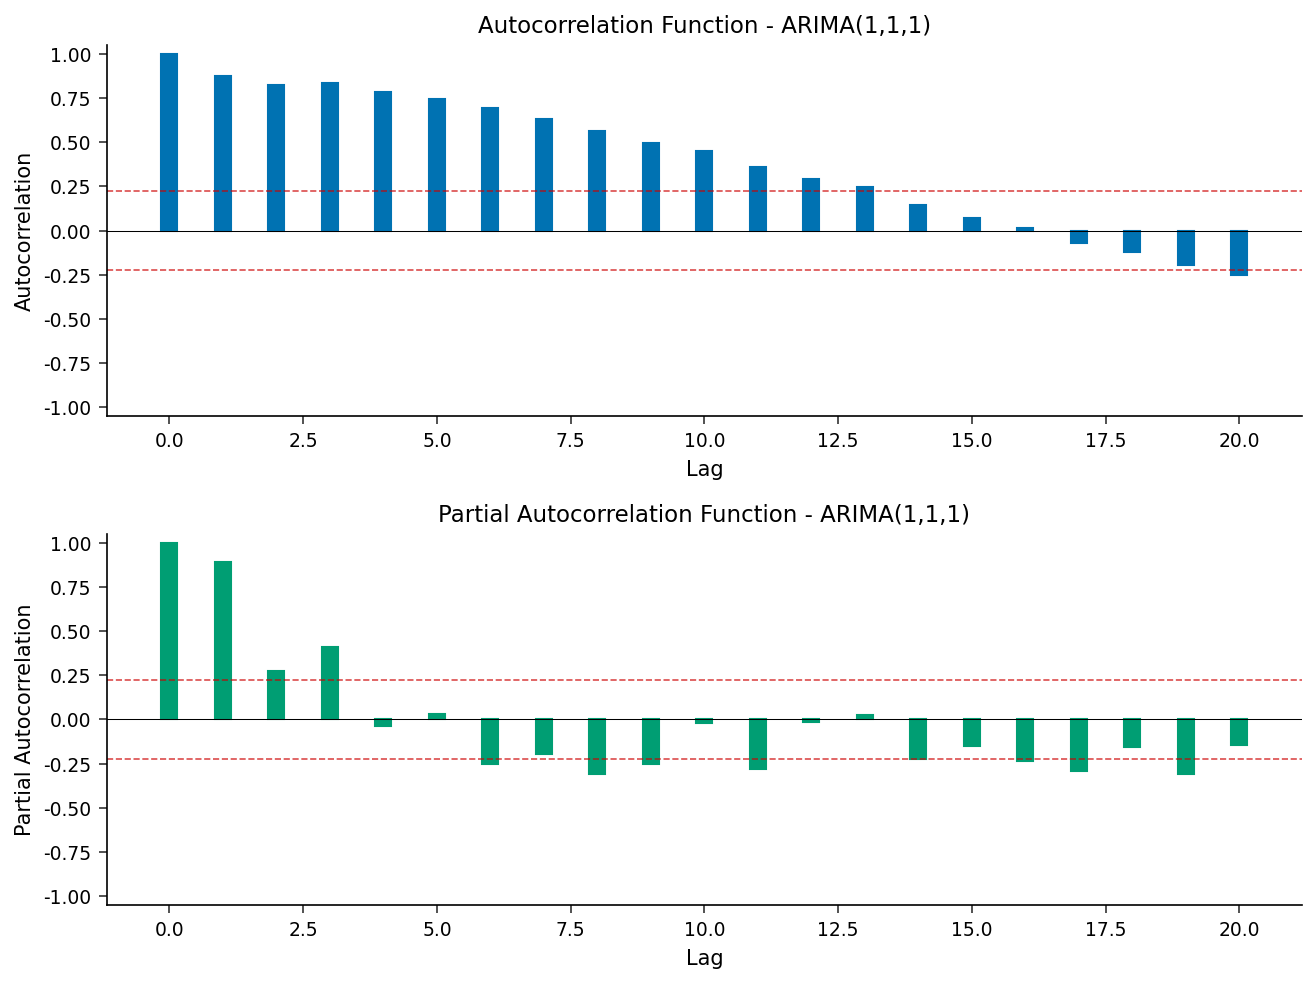

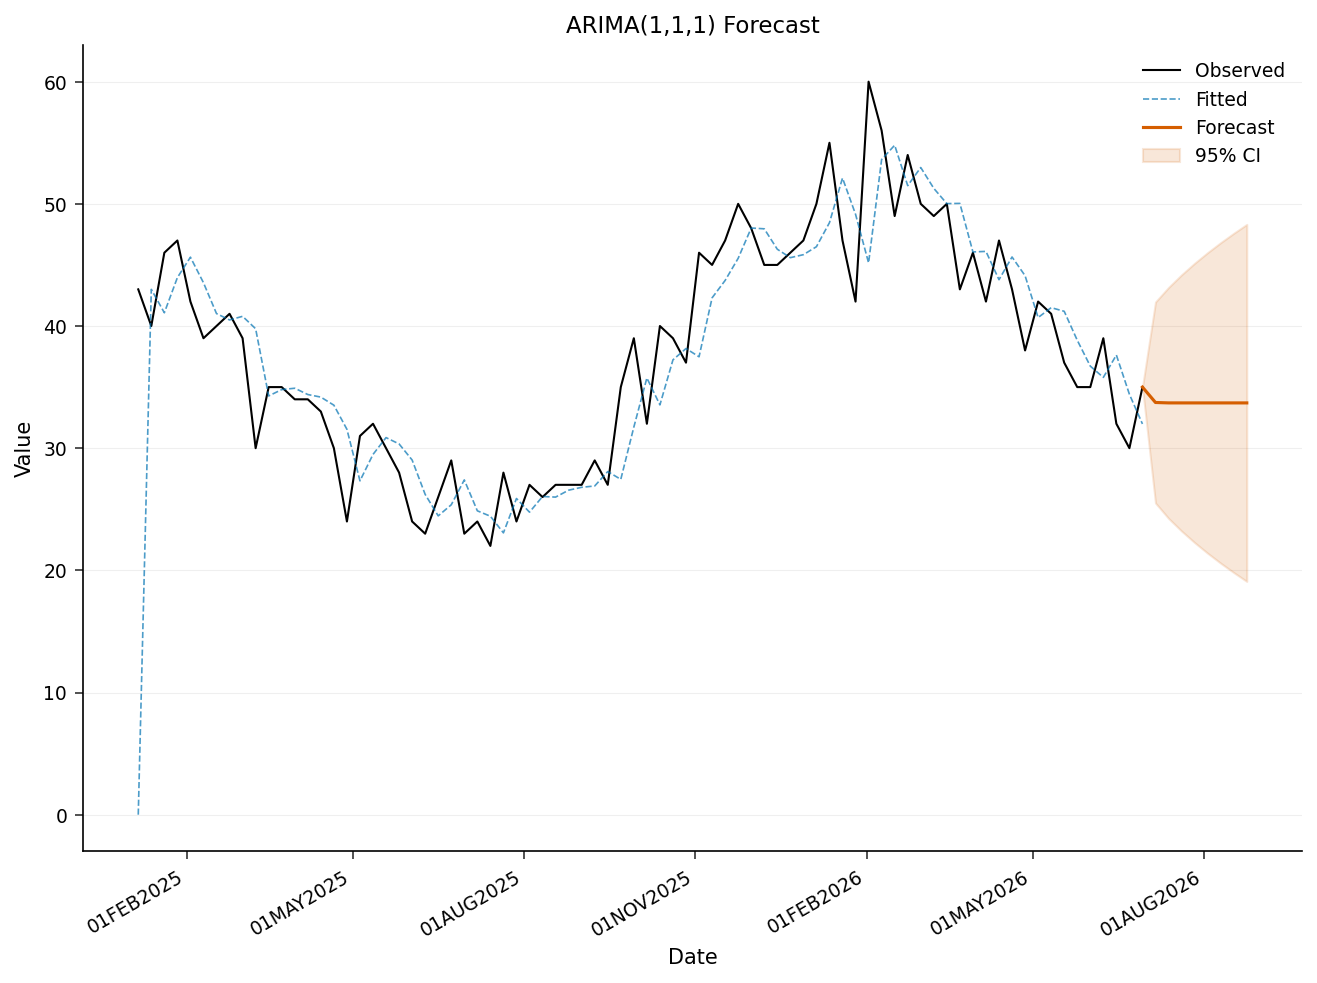

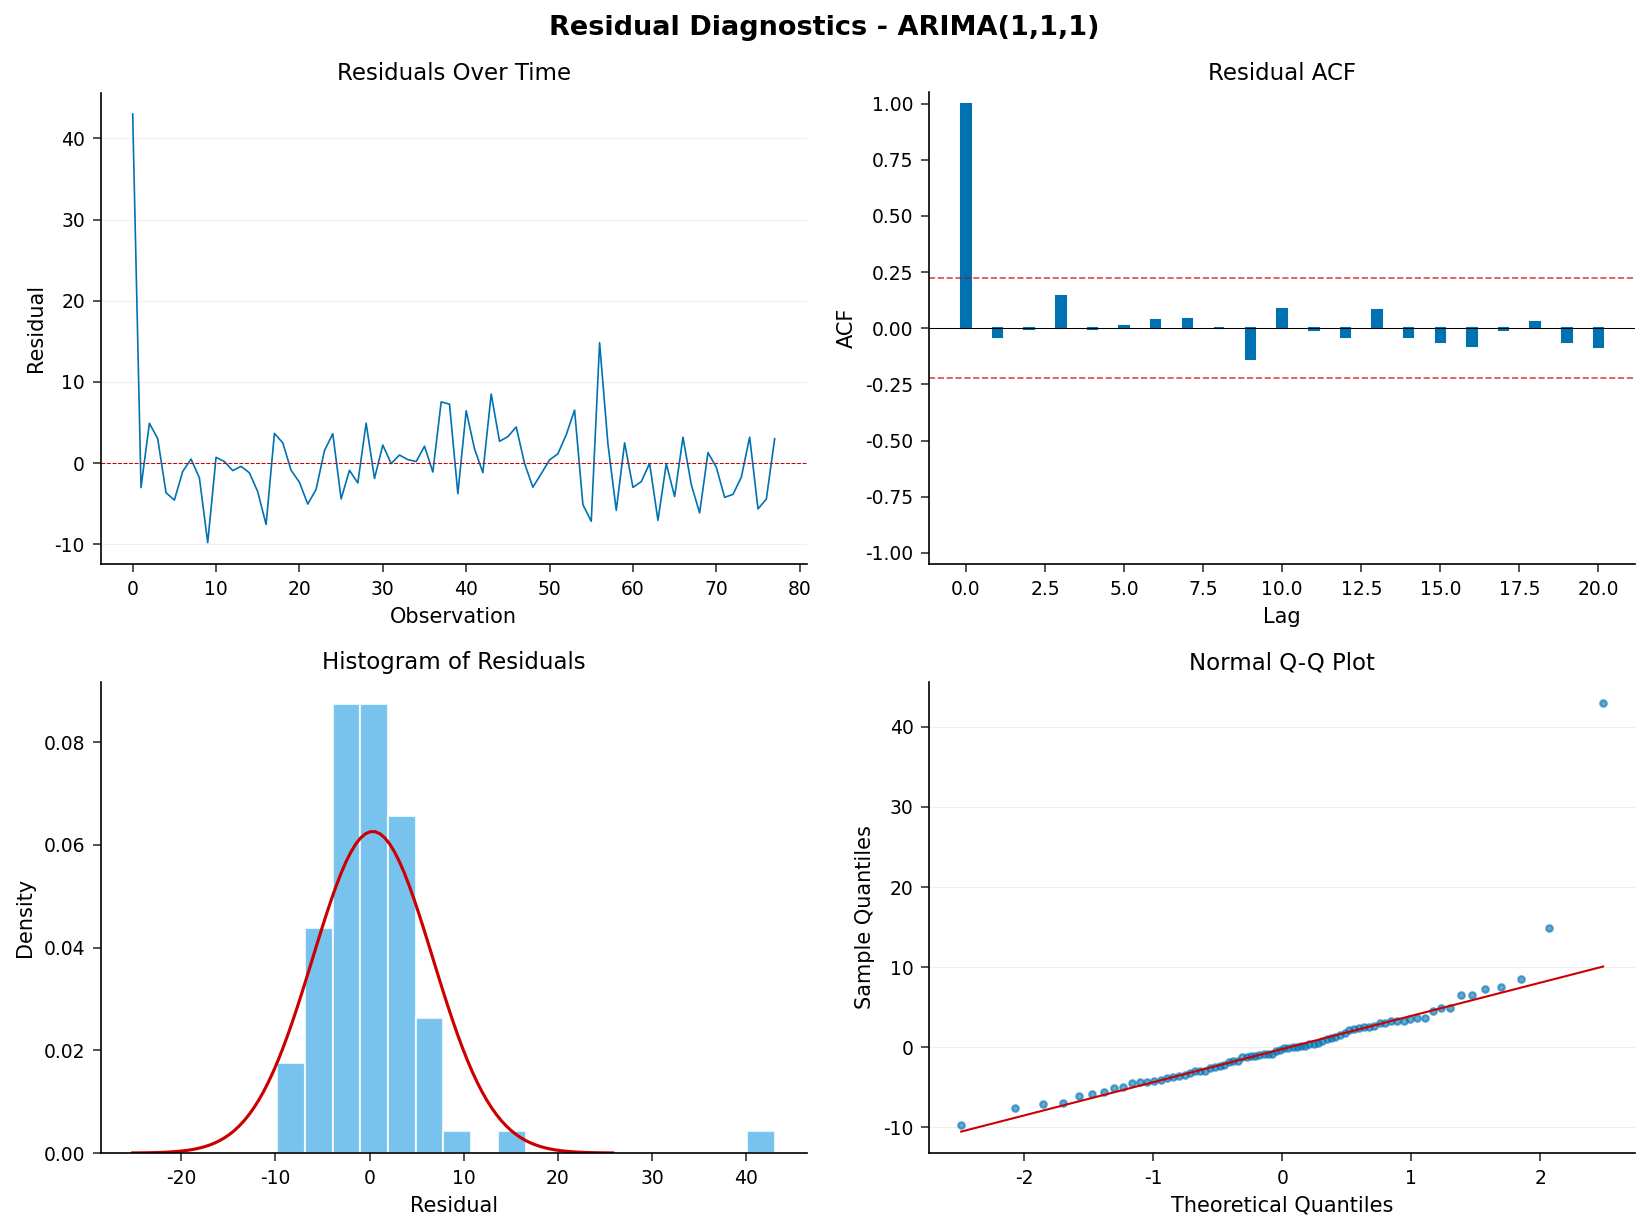

In [4]:
PROCEDURE ARIMA data=surveillance;
   IDENTIFY VARIABEL=cases(1) NLAG=20;
   ESTIMATE p=1 q=1;
   forecast LEAD=8 id=reportdate interval=week out=outbreak_fc;
   TITEL 'ARIMA(1,1,1)-tilpasning og 8-ugers prognose for tilfælde';
KØR;
QUIT;

### Prognosehorisont

Vi udskriver prognosedatasættet. De historiske rækker bærer ét-skridt-frem tilpassede værdier og residualer; de sidste 8 rækker (hvor `CASES` mangler) er den ægte ude-af-stikprøve-prognose, som enheden vil handle på, hver med et 95 %-prædiktionsinterval (`L95`/`U95`).

In [5]:
PROCEDURE UDSKRIV data=outbreak_fc(firstobs=71) noobs MÆRKAT;
   VARIABEL reportdate forecast std l95 u95 cases;
   MÆRKAT reportdate="Rapportdato" forecast="Prognose" std="Standardfejl"
       l95="Nedre 95%" u95="Øvre 95%" cases="Tilfælde";
   TITEL 'Prognosehorisont: næste 8 uger med 95% forudsigelsesgrænser';
KØR;

                              Prognosehorisont: næste 8 uger med 95% forudsigelsesgrænser                               

Rapportdato   Prognose  Standardfejl  Nedre 95%   Øvre 95%   Tilfælde
  11MAY2026   41.50232      4.198405  33.273596  49.731043         41
  18MAY2026   41.20542      4.198405  32.976697  49.434143         37
  25MAY2026  38.835772      4.198405  30.607049  47.064496         35
  01JUN2026  36.718147      4.198405  28.489423   44.94687         35
  08JUN2026  35.793373      4.198405   27.56465  44.022096         39
  15JUN2026  37.625431      4.198405  29.396708  45.854154         32
  22JUN2026  34.411883      4.198405   26.18316  42.640607         30
  29JUN2026  31.984172      4.198405  23.755449  40.212895         35
  06JUL2026  33.740066      4.198405  25.511343  41.968789          .
  13JUL2026  33.706638      4.821711  24.256259  43.157017          .
  20JUL2026  33.705751      5.351974  23.216075  44.195427          .
  27JUL2026  33.705728      5.833728  


NOTE: PROC PRINT data=outbreak_fc

NOTE: PROC PRINT completed: 16 observations printed, 6 variables


## 5. Fortolkning og beslutningsstøtte

**Hvad analysen leverer.**

- **Byrdebillede (MEANS).** Vinter og efterår er højbelastningssæsonerne, hvor vinteren også er den mest volatile — udgangspunktet for dimensionering af stående beredskabskapacitet.
- **Sæsonform (TIMESERIES).** Sæsonprofilen viser det tilbagevendende mønster inden for cyklussen, hvilket lader enheden time bemanding og opsøgende arbejde til de uger, der systematisk kører varmt, i stedet for at reagere bagefter.
- **Fremadrettet udsyn (ARIMA).** ARIMA(1,1,1)-prognosen giver, efter at tendensen er differentieret ud, 8 daterede ugentlige tilfælde-fremskrivninger med prædiktionsintervaller. Enheden placerer på forhånd laboratorie- og antiviral kapacitet mod den øvre (`U95`) grænse, så den ikke kommer til kort under en stigning, mens den bruger punktet `FORECAST` til den forventede bemanding.

**Forbehold og næste skridt.** Modellen fanger tendens og korttidshukommelsesdynamik, men ikke pludselige udbrudschok; prædiktionsintervallerne bliver bredere med horisonten, så 8-ugers-grænsen er bevidst. Med en længere historik ville et sæson-ARIMA-led (`sq=` på et 52-ugers lag) eller en interventions-/outlier-komponent skærpe prognosen. I produktion ville enheden gen-tilpasse ugentligt, efterhånden som nye rapporter ankommer, og overvåge residualer for tidlige tegn på et umodelleret udbrud.